## 🚀 **Week 1: Image Acquisition, EDA, and Preprocessing**

In [1]:
#Imports

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from collections import Counter

In [2]:
# INPUT
data_dir = Path(r"C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_color")


In [3]:
total_images = 0

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    
    if class_path.is_dir():
        num_images = len(os.listdir(class_path))
        total_images += num_images

print("Total Images:", total_images)

Total Images: 54305


In [4]:
#Exploratory Data Analysis(EDA)
#Class Distribution

class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    if class_path.is_dir():
        class_counts[class_name] = len(os.listdir(class_path))

# Print counts
for k, v in class_counts.items():
    print(f"{k}: {v}")

Apple___Apple_scab: 630
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry_(including_sour)___healthy: 854
Cherry_(including_sour)___Powdery_mildew: 1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn_(maize)___Common_rust_: 1192
Corn_(maize)___healthy: 1162
Corn_(maize)___Northern_Leaf_Blight: 985
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___healthy: 423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1478
Potato___Early_blight: 1000
Potato___healthy: 152
Potato___Late_blight: 1000
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___healthy: 456
Strawberry___Leaf_scorch: 1109
Tomato___Bacterial_spot: 2127
Tomato___Early_blight: 1000
Tomato___healthy: 1591
Tomato___Late_blight: 1909
Tomato___Leaf_Mold

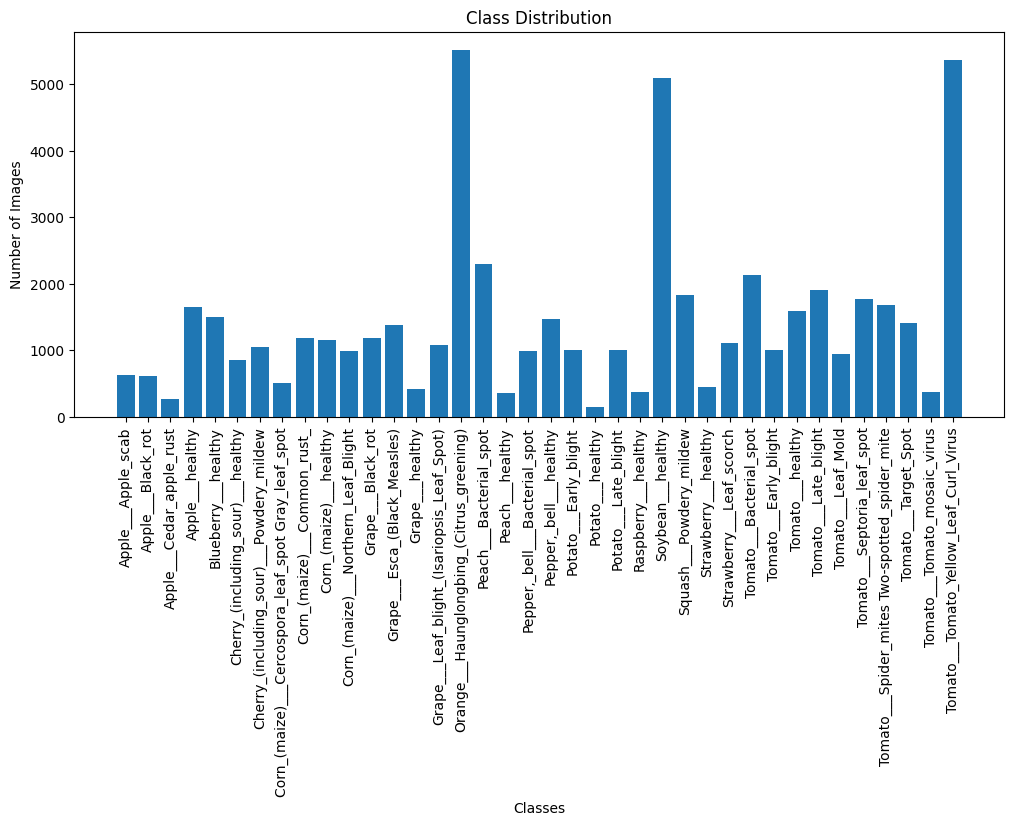

In [5]:
#Plot Class Distribution

plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

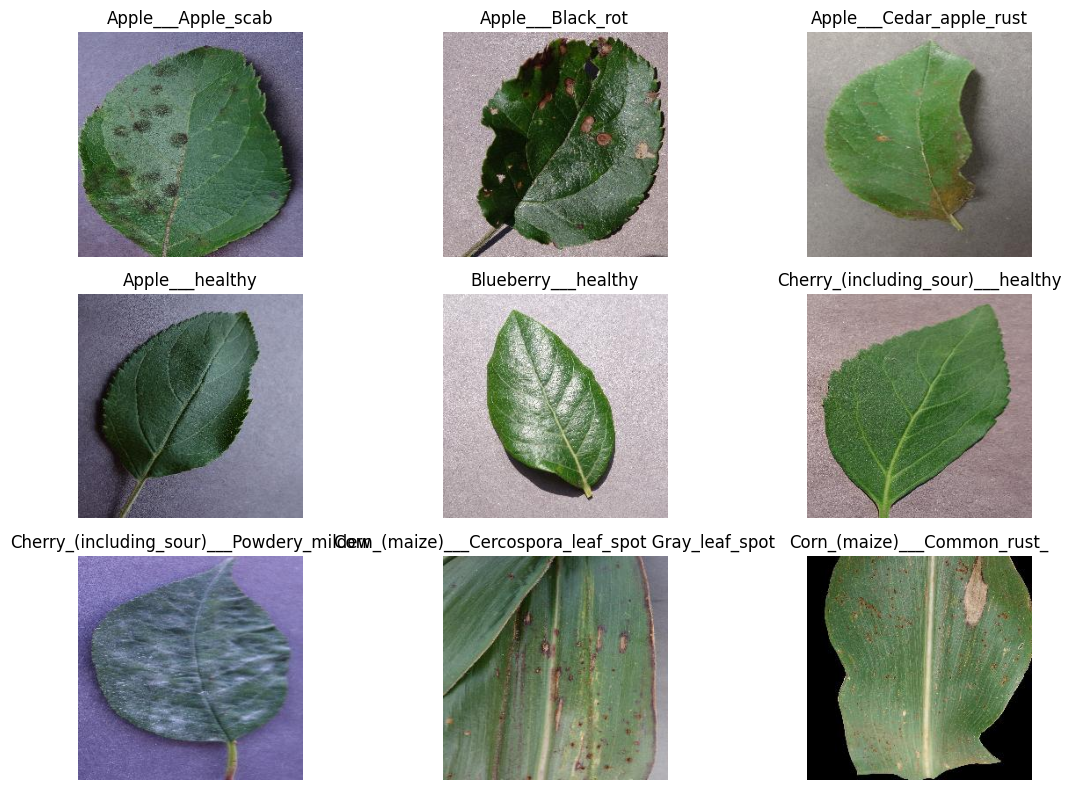

In [6]:
#Sample Image Visualization


plt.figure(figsize=(12,8))

classes = list(class_counts.keys())

for i, class_name in enumerate(classes[:9]):  # first 9 classes
    class_path = data_dir / class_name
    img_name = random.choice(os.listdir(class_path))
    img_path = class_path / img_name
    
    img = plt.imread(img_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
#Train/Val/Test Split
#Split Function

import shutil
# OUTPUT
output_dir = Path(r"C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split")

train_dir = output_dir / "train"
val_dir   = output_dir / "val"
test_dir  = output_dir / "test"


for folder in [train_dir, val_dir, test_dir]:
    folder.mkdir(parents=True, exist_ok=True)

train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

In [8]:
import os, shutil, random
from pathlib import Path

# ✅ INPUT DATASET
data_dir = Path(r"C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_color")

# ✅ OUTPUT
output_dir = Path(r"C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split")

train_dir = output_dir / "train"
test_dir  = output_dir / "test"
val_dir = output_dir / "val"

# ✅ clean old split (IMPORTANT)
if output_dir.exists():
    shutil.rmtree(output_dir)

train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)
val_dir.mkdir(parents=True, exist_ok=True)
for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name

    if not class_path.is_dir():
        continue

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random.shuffle(images)

    # ✅ CORRECT INDENTATION
    train_split = int(0.7 * len(images))
    val_split   = int(0.85 * len(images))

    train_images = images[:train_split]
    val_images   = images[train_split:val_split]
    test_images  = images[val_split:]

    for split_name, split_images in zip(
        ['train', 'val', 'test'],
        [train_images, val_images, test_images]
    ):
        split_dir = output_dir / split_name

        (split_dir / class_name).mkdir(parents=True, exist_ok=True)

        for img in split_images:
            src = class_path / img
            dst = split_dir / class_name / img

            shutil.copy2(src, dst)
print("✅ Data Split Done")

✅ Data Split Done


In [9]:
data_dir = Path(r"C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_color")

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [10]:
#Normalize + Prefetch

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))


AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)


In [11]:
def print_dataset_details(folder, name):
    print(f"\n📂 {name} Folder:")
    
    total = 0
    
    for class_name in os.listdir(folder):
        class_path = folder / class_name
        
        if class_path.is_dir():
            num_images = len(os.listdir(class_path))
            total += num_images
            print(f"{class_name}: {num_images}")
    
    print(f"👉 Total {name} Images: {total}")
print_dataset_details(train_dir, "Train")
print_dataset_details(val_dir, "Validation")
print_dataset_details(test_dir, "Test")


📂 Train Folder:
Apple___Apple_scab: 441
Apple___Black_rot: 434
Apple___Cedar_apple_rust: 192
Apple___healthy: 1151
Blueberry___healthy: 1051
Cherry_(including_sour)___healthy: 597
Cherry_(including_sour)___Powdery_mildew: 736
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 359
Corn_(maize)___Common_rust_: 834
Corn_(maize)___healthy: 813
Corn_(maize)___Northern_Leaf_Blight: 689
Grape___Black_rot: 826
Grape___Esca_(Black_Measles): 968
Grape___healthy: 296
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 753
Orange___Haunglongbing_(Citrus_greening): 3854
Peach___Bacterial_spot: 1607
Peach___healthy: 251
Pepper,_bell___Bacterial_spot: 697
Pepper,_bell___healthy: 1034
Potato___Early_blight: 700
Potato___healthy: 106
Potato___Late_blight: 700
Raspberry___healthy: 259
Soybean___healthy: 3563
Squash___Powdery_mildew: 1284
Strawberry___healthy: 319
Strawberry___Leaf_scorch: 776
Tomato___Bacterial_spot: 1488
Tomato___Early_blight: 700
Tomato___healthy: 1113
Tomato___Late_blight: 1336
Tomato___Le

## 🚀 **WEEK 2: Custom CNN Architecture and Baseline Training**

In [12]:
# =====================================================
# IMPORTS
# =====================================================
import os
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [13]:
# =====================================================
# PATHS
# =====================================================
base_dir = Path(r"C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split")
train_dir = base_dir / "train"
val_dir = base_dir / "val"
test_dir = base_dir / "test"

MODEL_PATH = "best_cnn_model.keras"

# =====================================================
# CONFIG
# =====================================================
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 500
NUM_CLASSES = len(os.listdir(train_dir)) #Auto-detect number of class

print(f"Train : {train_dir}")
print(f" Val : {val_dir}")
print(f" Test : {test_dir}")
print(f" Number of Classes : {NUM_CLASSES}")

Train : C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split\train
 Val : C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split\val
 Test : C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split\test
 Number of Classes : 38


In [14]:
# =====================================================
# DATA GENERATOR
# =====================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)


NUM_CLASSES= len(train_generator.class_indices)
print(f" Classes loaded: {NUM_CLASSES} classes")
print(f" Train batches : {len(train_generator)}")
print(f" val batches : {len(val_generator)}")
print(f" Test batches : {len(test_generator)}")




Found 37997 images belonging to 38 classes.
Found 8146 images belonging to 38 classes.
Found 8162 images belonging to 38 classes.
 Classes loaded: 38 classes
 Train batches : 2375
 val batches : 510
 Test batches : 511


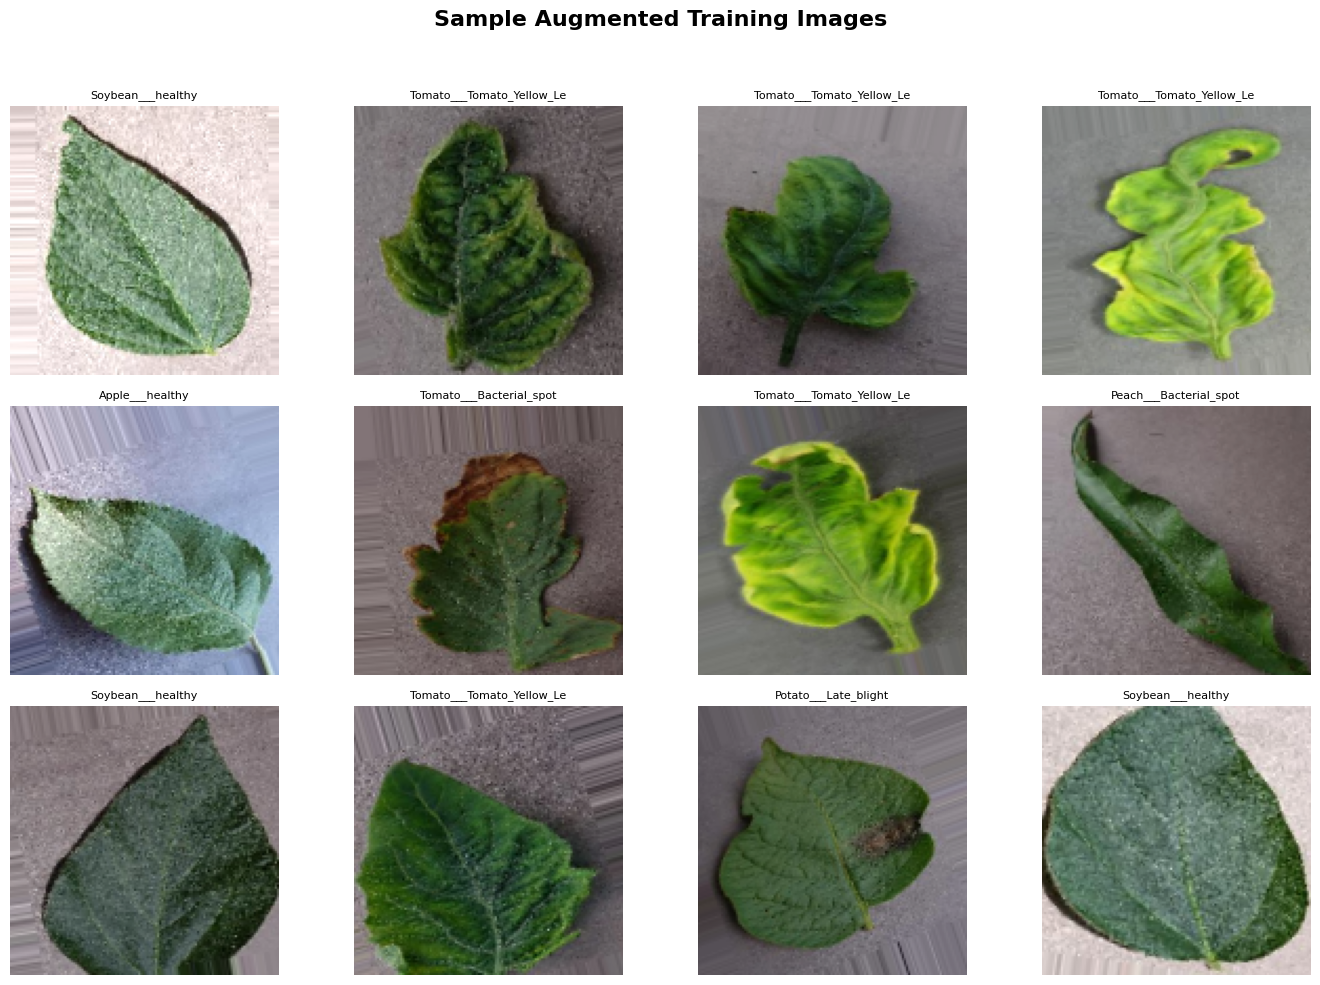

Augmented Sample images displayed


In [15]:
# Visualize Augmented Images (sanity check)
import matplotlib.pyplot as plt
import numpy as np

class_names = list(train_generator.class_indices.keys())

sample_batch, sample_labels = next(train_generator)

fig, axes = plt.subplots(3, 4, figsize =(14, 10))
fig.suptitle('Sample Augmented Training Images', fontsize= 16, fontweight= 'bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch[i])
    label_idx = np.argmax(sample_labels[i])
    ax.set_title(class_names[label_idx][:25],fontsize=8)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('augmented_samples.png',dpi =100, bbox_inches='tight')
plt.show()
print("Augmented Sample images displayed")

In [16]:
# =====================================================
# MODEL
# =====================================================
def build_custom_cnn(num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model
    

num_classes = 38  
model = build_custom_cnn(num_classes)

model.summary()

C:\Users\Prarthana\.conda\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 136,038 (531.40 KB)

 Trainable params: 136,038 (531.40 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# =====================================================
# CALLBACKS
# =====================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print(f"✅ Calbacks configured")
print("   • EarlyStopping    (patience=5) ")
print("   • ModelCheckpoint  (save best model)")
print("   • ReduceLROnPlateau (patience=3)")


✅ Calbacks configured
   • EarlyStopping    (patience=5) 
   • ModelCheckpoint  (save best model)
   • ReduceLROnPlateau (patience=3)


In [18]:
print("Train:", len(train_generator.class_indices))
print("Val:", len(val_generator.class_indices))

print("\nTrain classes:")
print(train_generator.class_indices)

print("\nVal classes:")
print(val_generator.class_indices)

Train: 38
Val: 38

Train classes:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, '

In [19]:
# =====================================================
# 🔥 FIRST TRAINING
# =====================================================
print("\n🚀 FIRST TRAINING STARTED")

model = build_custom_cnn(NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("✅ First training done")



🚀 FIRST TRAINING STARTED


C:\Users\Prarthana\.conda\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.2523 - loss: 2.8039  
Epoch 1: val_accuracy improved from None to 0.59968, saving model to best_cnn_model.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 398s 167ms/step - accuracy: 0.3542 - loss: 2.3376 - val_accuracy: 0.5997 - val_loss: 1.3868 - learning_rate: 0.0010
Epoch 2/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5593 - loss: 1.4823  
Epoch 2: val_accuracy improved from 0.59968 to 0.64842, saving model to best_cnn_model.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 211s 89ms/step - accuracy: 0.5967 - loss: 1.3486 - val_accuracy: 0.6484 - val_loss: 1.1922 - learning_rate: 0.0010
Epoch 3/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6659 - loss: 1.1083  
Epoch 3: val_accuracy improved from 0.64842 to 0.75153, saving model to best_cnn_model.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 206s 87ms/step - accuracy: 0.6846 - loss: 1.0385 - val_accuracy: 0.7515 - val_loss: 0.7736 - learning_rate: 0.0010
Epoch 4/

In [20]:
# =====================================================
# 🔥 LOAD BEST MODEL
# =====================================================
print("\n🔁 Loading BEST model for second training...")
model = tf.keras.models.load_model(MODEL_PATH)

# Lower LR for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


🔁 Loading BEST model for second training...


In [21]:
# =====================================================
# 🔥 SECOND TRAINING
# =====================================================
print("\n🚀 SECOND TRAINING STARTED")

history2 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("✅ Second training done")



🚀 SECOND TRAINING STARTED
Epoch 1/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9680 - loss: 0.0996  
Epoch 1: val_accuracy did not improve from 0.95556
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 210s 88ms/step - accuracy: 0.9683 - loss: 0.0991 - val_accuracy: 0.9402 - val_loss: 0.2512 - learning_rate: 1.0000e-04
Epoch 2/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9704 - loss: 0.0920  
Epoch 2: val_accuracy did not improve from 0.95556
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 209s 88ms/step - accuracy: 0.9689 - loss: 0.0937 - val_accuracy: 0.9482 - val_loss: 0.2113 - learning_rate: 1.0000e-04
Epoch 3/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9687 - loss: 0.0971  
Epoch 3: val_accuracy did not improve from 0.95556
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 210s 88ms/step - accuracy: 0.9687 - loss: 0.0955 - val_accuracy: 0.9348 - val_loss: 0.2893 - learning_rate: 1.0000e-04
Epoch 4/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9685 - loss: 0.0959  
Ep

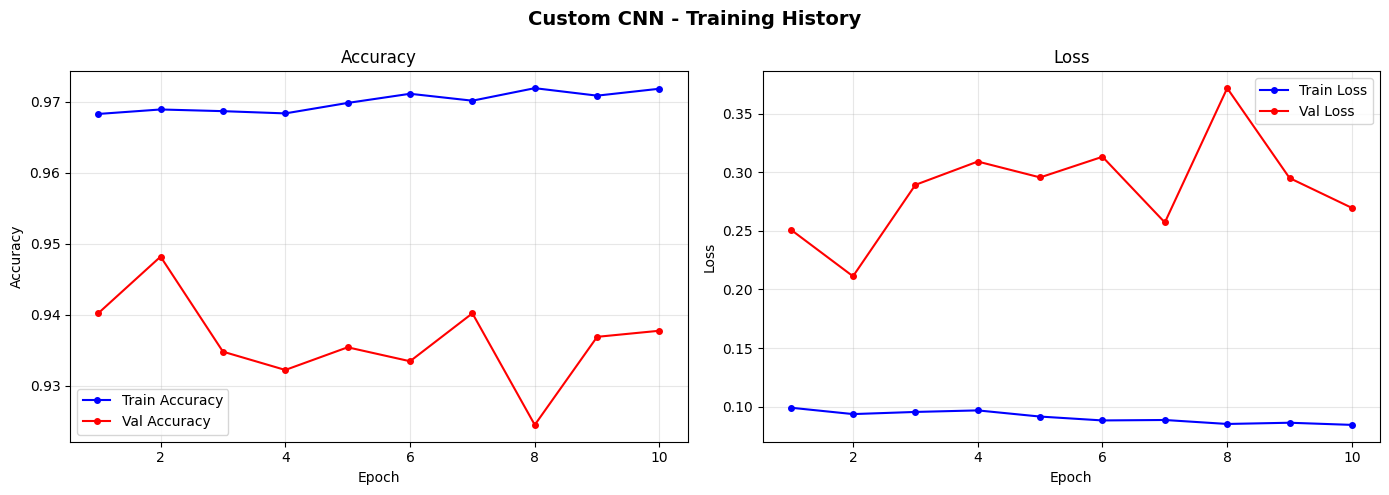


🔥 Best Validation Accuracy: 0.9482 (94.82%)

🧪 Testing final best model...
511/511 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - accuracy: 0.9597 - loss: 0.1782
🔥 Final Test Accuracy: 0.9597


In [22]:
import matplotlib.pyplot as plt
import tensorflow as tf

# =====================================================
# PLOT FUNCTION
# =====================================================
def plot_training_history(history, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} - Training History', fontsize=14, fontweight='bold')

    epochs_ran = range(1, len(history.history['accuracy']) + 1)

    # Accuracy Plot
    axes[0].plot(epochs_ran, history.history['accuracy'], 'b-o', label='Train Accuracy', markersize=4)
    axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Val Accuracy', markersize=4)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss Plot
    axes[1].plot(epochs_ran, history.history['loss'], 'b-o', label='Train Loss', markersize=4)
    axes[1].plot(epochs_ran, history.history['val_loss'], 'r-o', label='Val Loss', markersize=4)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_history.png', dpi=100, bbox_inches='tight')
    plt.show()


# =====================================================
# SELECT WHICH HISTORY TO USE 👇
# =====================================================
history = history2   # 👉 jodi 2nd training use korte chao
# history = history1  # 👉 jodi sudhu 1st training use korte chao


# =====================================================
# RUN PLOT + BEST VAL ACC
# =====================================================
plot_training_history(history, "Custom CNN")

if 'val_accuracy' in history.history:
    best_val_acc = max(history.history['val_accuracy'])
    print(f"\n🔥 Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
else:
    print("⚠️ No validation accuracy found!")


# =====================================================
# TEST BEST MODEL
# =====================================================
print("\n🧪 Testing final best model...")

model = tf.keras.models.load_model(MODEL_PATH)

test_loss, test_acc = model.evaluate(test_generator)

print(f"🔥 Final Test Accuracy: {test_acc:.4f}")

In [23]:
# ===============================
# 📊 FINAL ACCURACY REPORT
# ===============================

print("\n📊 FINAL MODEL PERFORMANCE")

# 👉 Training Accuracy (last epoch)
train_acc = history.history['accuracy'][-1]

# 👉 Validation Accuracy (best)
val_acc = max(history.history['val_accuracy'])

# 👉 Test Accuracy (already calculated)
# test_acc = model.evaluate(test_generator) theke peye gecho

print(f"✅ Train Accuracy     : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"✅ Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"✅ Test Accuracy      : {test_acc:.4f} ({test_acc*100:.2f}%)")


📊 FINAL MODEL PERFORMANCE
✅ Train Accuracy     : 0.9718 (97.18%)
✅ Validation Accuracy: 0.9482 (94.82%)
✅ Test Accuracy      : 0.9597 (95.97%)


## 🚀 **Week 3: Transfer Learning and Hyperparameter Optimization**

In [24]:
# =====================================================
# Imports
# =====================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [25]:
# ── Dataset paths ──────────────────────────────
base_dir = Path(r"C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split")

train_dir = base_dir / "train"
val_dir   = base_dir / "val"
test_dir  = base_dir / "test"

# Week-2 model path (used for baseline comparison)
WEEK2_MODEL_PATH = "best_cnn_model.keras"

# Week-3 best model will be saved here
WEEK3_MODEL_PATH = "week3_best_transfer_model.keras"

# ── Config ──────────────────────────────────────────────────────────
# MobileNetV2 requires 224×224 input (upgraded from Week 2's 128×128)
IMG_SIZE   = 224
BATCH_SIZE = 32   # increased from 16; 224px images fit fine in GPU memory
EPOCHS     = 200

NUM_CLASSES = len(os.listdir(train_dir))

print(f"Train : {train_dir}")
print(f"Val   : {val_dir}")
print(f"Test  : {test_dir}")
print(f"\n📊 Number of classes detected: {NUM_CLASSES}")

Train : C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split\train
Val   : C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split\val
Test  : C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split\test

📊 Number of classes detected: 38


In [26]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes

print(f"\n✅ Generators ready")
print(f"   Train batches : {len(train_generator)}")
print(f"   Val batches   : {len(val_generator)}")
print(f"   Test batches  : {len(test_generator)}")
print(f"   Classes       : {NUM_CLASSES}")

Found 37997 images belonging to 38 classes.
Found 8146 images belonging to 38 classes.
Found 8162 images belonging to 38 classes.

✅ Generators ready
   Train batches : 1188
   Val batches   : 255
   Test batches  : 256
   Classes       : 38


In [27]:
#Load Week-2 Baseline for Comparison

print("=" * 55)
print("📦 LOADING WEEK-2 BASELINE MODEL FOR COMPARISON")
print("=" * 55)

# Week-2 used 128×128 — build a separate 128×128 test generator just for this
val_test_datagen_128 = ImageDataGenerator(rescale=1./255)
test_generator_128 = val_test_datagen_128.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

try:
    baseline_model = tf.keras.models.load_model(WEEK2_MODEL_PATH)
    baseline_loss, baseline_acc = baseline_model.evaluate(test_generator_128, verbose=0)
    print(f"\n✅ Week-2 Baseline Test Accuracy : {baseline_acc * 100:.2f}%")
    BASELINE_ACC = baseline_acc
except Exception as e:
    print(f"⚠️  Could not load Week-2 model: {e}")
    print("    (Comparison will be skipped at the end)")
    BASELINE_ACC = None

📦 LOADING WEEK-2 BASELINE MODEL FOR COMPARISON
Found 8162 images belonging to 38 classes.


C:\Users\Prarthana\.conda\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



✅ Week-2 Baseline Test Accuracy : 95.97%


In [28]:
#Build Transfer Learning Model

def build_transfer_model(learning_rate=0.0001):
    """
    Transfer Learning model using MobileNetV2 pretrained on ImageNet.
    Base layers are frozen; only the custom classification head is trained
    in Phase 1. Fine-tuning (Phase 2) unlocks the last 30 base layers.
    """
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False   # freeze all pretrained layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

print("✅ build_transfer_model() defined")

✅ build_transfer_model() defined


In [29]:
#Hyperparameter Experiment — Learning Rate Search

print("=" * 55)
print("🔬 HYPERPARAMETER EXPERIMENT: Learning Rate Search")
print("=" * 55)
print("Testing lr = 0.001  vs  lr = 0.0001 (5 quick epochs each)\n")

best_val_acc = 0
best_lr      = None

for lr in [0.001, 0.0001]:
    print(f"\n--- lr = {lr} ---")

    model_exp, _ = build_transfer_model(learning_rate=lr)

    early_stop_exp = EarlyStopping(
        monitor="val_loss", patience=3,
        restore_best_weights=True, verbose=0
    )
    reduce_lr_exp = ReduceLROnPlateau(
        monitor="val_loss", factor=0.3,
        patience=2, min_lr=1e-7, verbose=0
    )

    history_exp = model_exp.fit(
        train_generator,
        validation_data=val_generator,
        epochs=50,
        callbacks=[early_stop_exp, reduce_lr_exp],
        verbose=1
    )

    final_val_acc = max(history_exp.history["val_accuracy"])
    print(f"  → Best val_accuracy : {final_val_acc:.4f}")

    if final_val_acc > best_val_acc:
        best_val_acc = final_val_acc
        best_lr      = lr

print(f"\n✅ Best learning rate selected : {best_lr}  (val_acc = {best_val_acc:.4f})")

🔬 HYPERPARAMETER EXPERIMENT: Learning Rate Search
Testing lr = 0.001  vs  lr = 0.0001 (5 quick epochs each)


--- lr = 0.001 ---
Epoch 1/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 523s 438ms/step - accuracy: 0.8282 - loss: 0.5829 - val_accuracy: 0.9240 - val_loss: 0.2351 - learning_rate: 0.0010
Epoch 2/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 515s 433ms/step - accuracy: 0.8939 - loss: 0.3380 - val_accuracy: 0.9332 - val_loss: 0.2050 - learning_rate: 0.0010
Epoch 3/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 513s 432ms/step - accuracy: 0.9036 - loss: 0.2968 - val_accuracy: 0.9405 - val_loss: 0.1784 - learning_rate: 0.0010
Epoch 4/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 513s 431ms/step - accuracy: 0.9114 - loss: 0.2707 - val_accuracy: 0.9386 - val_loss: 0.1838 - learning_rate: 0.0010
Epoch 5/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 514s 433ms/step - accuracy: 0.9187 - loss: 0.2504 - val_accuracy: 0.9450 - val_loss: 0.1711 - learning_rate: 0.0010
Epoch 6/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 515s 433ms/step - accuracy: 0.9205 - lo

In [30]:
#Phase 1 — Full Training (Frozen Base)

print("=" * 55)
print("🚀 PHASE 1 — FULL TRAINING WITH BEST LR (frozen base)")
print("=" * 55)

model, base_model = build_transfer_model(learning_rate=best_lr)
model.summary()

early_stop_p1 = EarlyStopping(
    monitor="val_loss", patience=6,
    restore_best_weights=True, verbose=1
)
checkpoint_p1 = ModelCheckpoint(
    WEEK3_MODEL_PATH, monitor="val_accuracy",
    save_best_only=True, verbose=1
)
reduce_lr_p1 = ReduceLROnPlateau(
    monitor="val_loss", factor=0.3,
    patience=3, min_lr=1e-7, verbose=1
)

history_transfer = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop_p1, checkpoint_p1, reduce_lr_p1],
    verbose=1
)

print("✅ Phase 1 training complete")

🚀 PHASE 1 — FULL TRAINING WITH BEST LR (frozen base)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,600,806 (9.92 MB)

 Trainable params: 340,262 (1.30 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/200
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.5055 - loss: 1.9656  
Epoch 1: val_accuracy improved from None to 0.87073, saving model to week3_best_transfer_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 532s 446ms/step - accuracy: 0.6675 - loss: 1.2409 - val_accuracy: 0.8707 - val_loss: 0.4276 - learning_rate: 1.0000e-04
Epoch 2/200
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8315 - loss: 0.5667  
Epoch 2: val_accuracy improved from 0.87073 to 0.90805, saving model to week3_best_transfer_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 517s 435ms/step - accuracy: 0.8424 - loss: 0.5191 - val_accuracy: 0.9081 - val_loss: 0.2910 - learning_rate: 1.0000e-04
Epoch 3/200
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8699 - loss: 0.4167  
Epoch 3: val_accuracy improved from 0.90805 to 0.91972, saving model to week3_best_transfer_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 518s 436ms/step - accuracy: 0.8744 - loss: 0.3982 - val_accuracy: 0.9197 - val_

In [31]:
#Phase 2 — Fine-Tuning

print("=" * 55)
print("🔧 PHASE 2 — FINE-TUNING (last 30 MobileNetV2 layers)")
print("=" * 55)

base_model.trainable = True

# Keep earlier feature-extractor layers frozen
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a very small lr to avoid destroying pretrained weights
model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Fresh callbacks — never reuse Phase 1 callbacks
early_stop_p2 = EarlyStopping(
    monitor="val_loss", patience=6,
    restore_best_weights=True, verbose=1
)
checkpoint_p2 = ModelCheckpoint(
    WEEK3_MODEL_PATH, monitor="val_accuracy",
    save_best_only=True, verbose=1
)
reduce_lr_p2 = ReduceLROnPlateau(
    monitor="val_loss", factor=0.3,
    patience=3, min_lr=1e-8, verbose=1
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,
    callbacks=[early_stop_p2, checkpoint_p2, reduce_lr_p2],
    verbose=1
)

print("✅ Phase 2 fine-tuning complete")

🔧 PHASE 2 — FINE-TUNING (last 30 MobileNetV2 layers)
Epoch 1/200
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8563 - loss: 0.4600  
Epoch 1: val_accuracy improved from None to 0.94144, saving model to week3_best_transfer_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 594s 496ms/step - accuracy: 0.8773 - loss: 0.3853 - val_accuracy: 0.9414 - val_loss: 0.1984 - learning_rate: 5.0000e-06
Epoch 2/200
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9080 - loss: 0.2806  
Epoch 2: val_accuracy improved from 0.94144 to 0.94807, saving model to week3_best_transfer_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 581s 489ms/step - accuracy: 0.9126 - loss: 0.2681 - val_accuracy: 0.9481 - val_loss: 0.1635 - learning_rate: 5.0000e-06
Epoch 3/200
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9197 - loss: 0.2428  
Epoch 3: val_accuracy improved from 0.94807 to 0.95065, saving model to week3_best_transfer_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 583s 491ms/step - accuracy

In [32]:
#Load Best Model & Evaluate

print("=" * 55)
print("📊 EVALUATING BEST WEEK-3 MODEL")
print("=" * 55)

best_model = tf.keras.models.load_model(WEEK3_MODEL_PATH)

val_loss, val_acc   = best_model.evaluate(val_generator,  verbose=0)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=0)

print(f"\nValidation Accuracy : {val_acc  * 100:.2f}%")
print(f"Test Accuracy       : {test_acc * 100:.2f}%")

📊 EVALUATING BEST WEEK-3 MODEL

Validation Accuracy : 98.08%
Test Accuracy       : 97.94%


In [33]:
#Classification Report — Precision, Recall & F1

print("=" * 55)
print("📋 CLASSIFICATION REPORT")
print("=" * 55)

test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes
class_names  = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

📋 CLASSIFICATION REPORT
256/256 ━━━━━━━━━━━━━━━━━━━━ 71s 274ms/step 
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.97      0.98        95
                                 Apple___Black_rot       0.99      1.00      0.99        94
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        42
                                   Apple___healthy       0.99      0.98      0.99       247
                               Blueberry___healthy       0.99      1.00      1.00       226
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       158
                 Cherry_(including_sour)___healthy       0.99      1.00      1.00       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.82      0.90      0.86        77
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       179
          

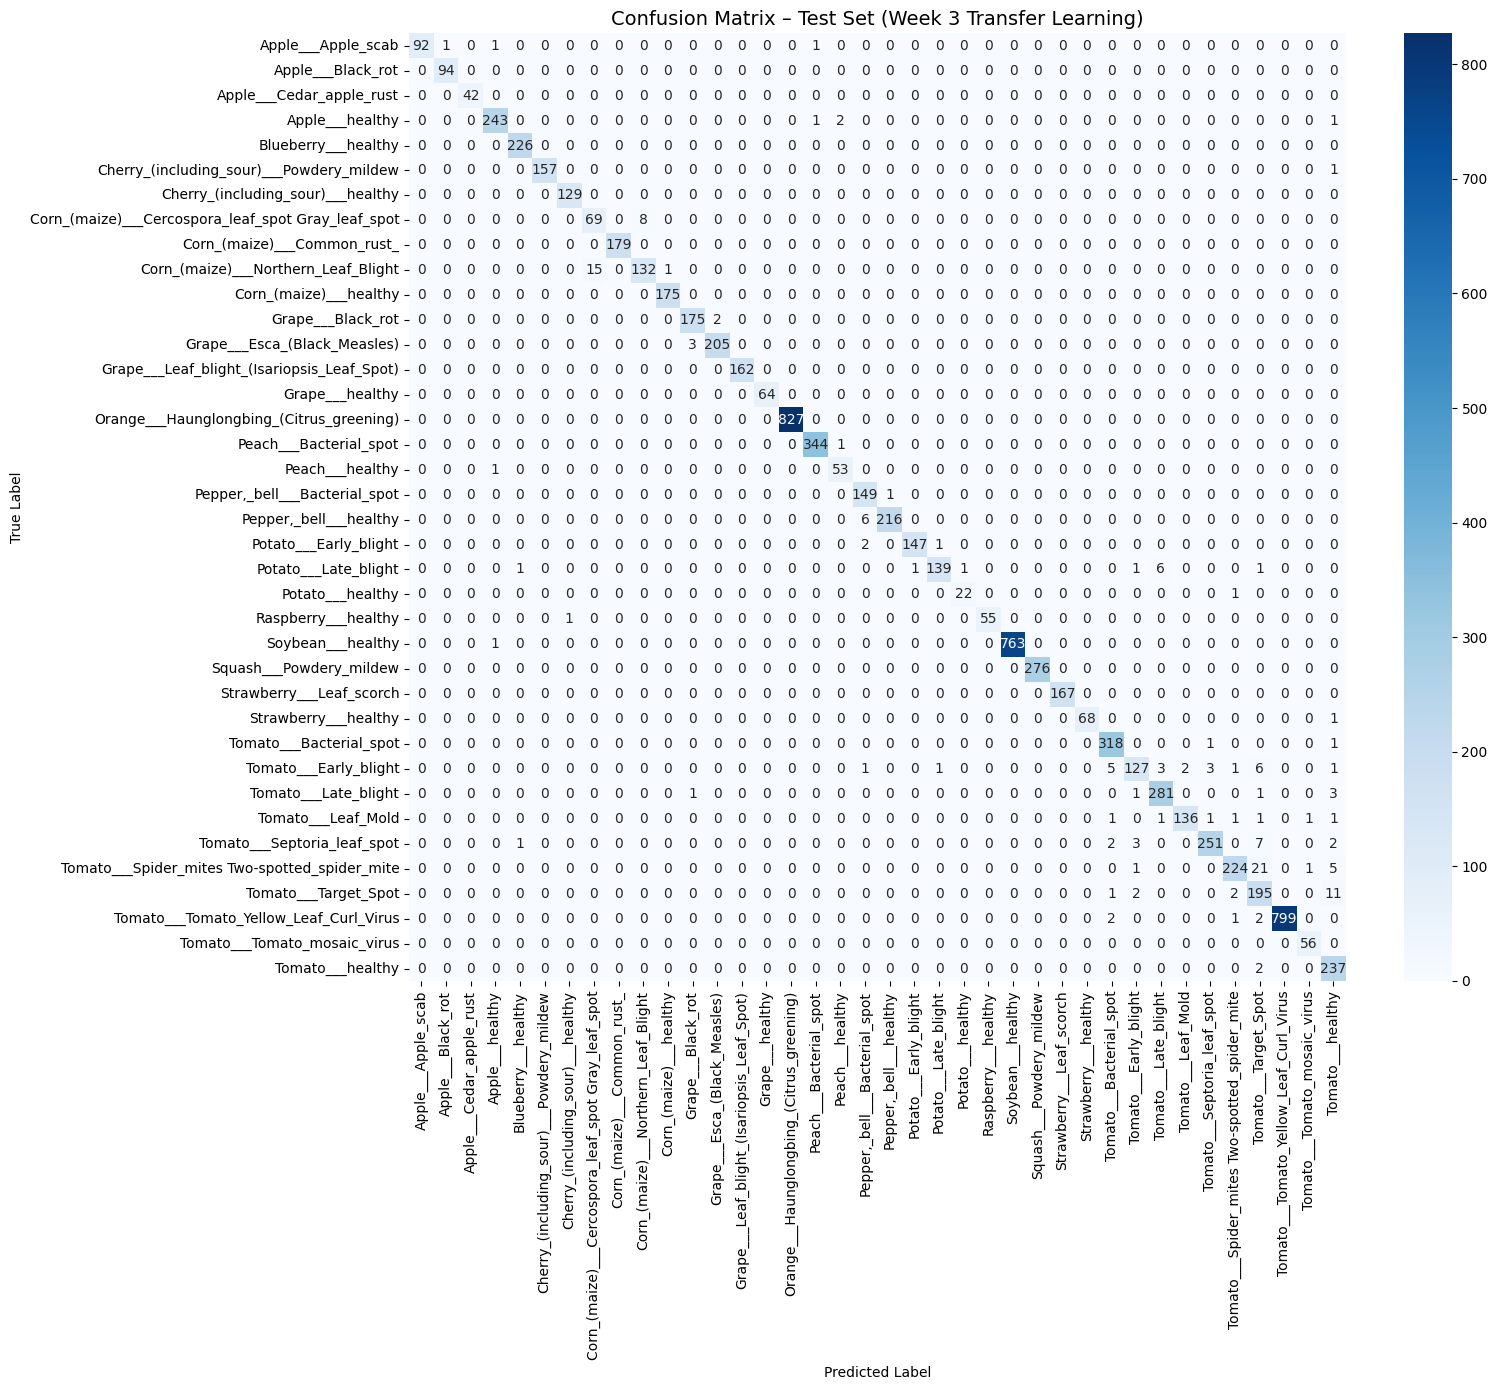

✅ Confusion matrix saved → week3_confusion_matrix.png


In [34]:
#Confusion Matrix

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        cm,
        annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title("Confusion Matrix – Test Set (Week 3 Transfer Learning)", fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("week3_confusion_matrix.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("✅ Confusion matrix saved → week3_confusion_matrix.png")

plot_confusion_matrix(y_true, y_pred, class_names)

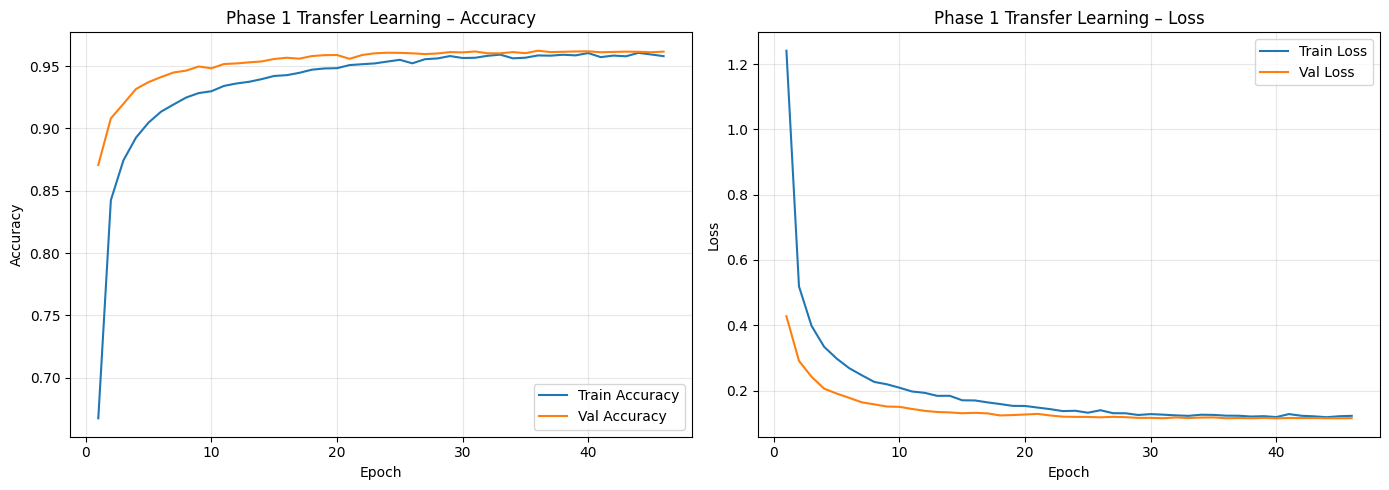

✅ Training curve saved → Phase_1_Transfer_Learning.png


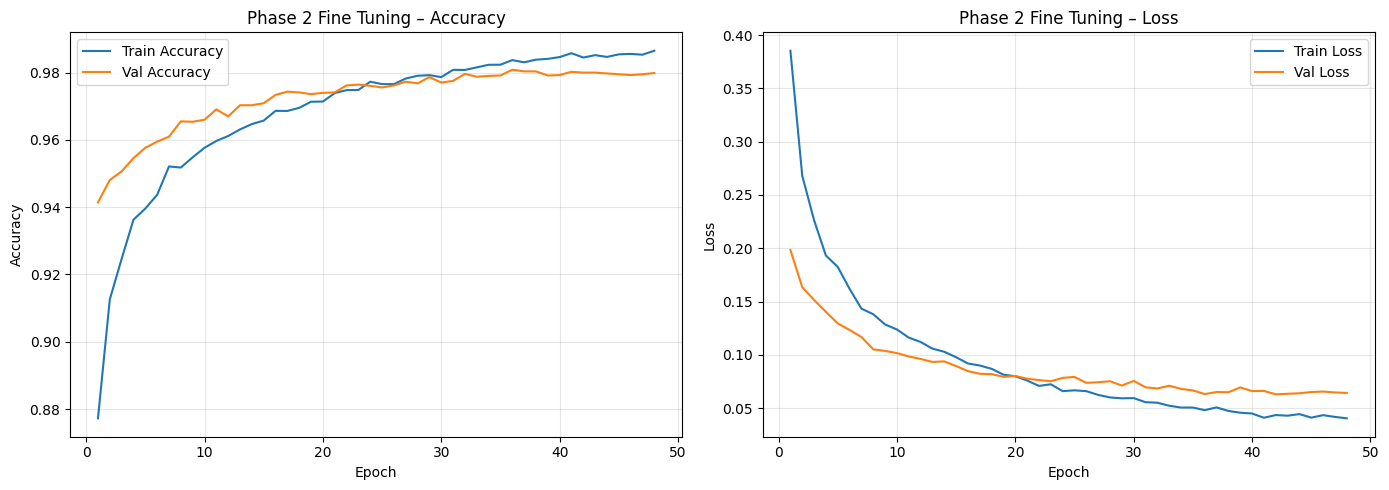

✅ Training curve saved → Phase_2_Fine_Tuning.png


In [35]:
#Training Curves — Phase 1 & Phase 2

def plot_history(history, title):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc,     label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Val Accuracy")
    plt.title(title + " – Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss,     label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.title(title + " – Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = title.replace(" ", "_").replace("(", "").replace(")", "") + ".png"
    plt.savefig(fname, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"✅ Training curve saved → {fname}")

plot_history(history_transfer, "Phase 1 Transfer Learning")
plot_history(history_finetune,  "Phase 2 Fine Tuning")

In [37]:
##### Week-by-Week Progress Summary
print("=" * 55)
print("📈 WEEK-BY-WEEK PROGRESS SUMMARY")
print("=" * 55)

if BASELINE_ACC is not None:
    improvement = (test_acc - BASELINE_ACC) * 100
    print(f"  Week 2  – Custom CNN (128×128)           : {BASELINE_ACC * 100:.2f}%")
    print(f"  Week 3  – MobileNetV2 Transfer (224×224) : {test_acc * 100:.2f}%")
    print(f"  Improvement                              : +{improvement:.2f}%")
else:
    print(f"  Week 3 – MobileNetV2 Transfer Learning Test Accuracy: {test_acc * 100:.2f}%")
    print("  (Week-2 baseline not available for comparison)")

print("\n✅ Week 3 complete!")
print(f"   Best model saved at : {WEEK3_MODEL_PATH}")

📈 WEEK-BY-WEEK PROGRESS SUMMARY
  Week 2  – Custom CNN (128×128)           : 95.97%
  Week 3  – MobileNetV2 Transfer (224×224) : 97.94%
  Improvement                              : +1.97%

✅ Week 3 complete!
   Best model saved at : week3_best_transfer_model.keras
